# MF728 — SOFR Yield Curve Construction
**Valuation Date:** March 18, 2026

**Method A:** Bootstrap from `curve_construction_inputs.csv` + `sofr_futures_with_cvxadj.csv`  
**Method B:** Direct read-in from `sofr_zero_curve.csv` (Bloomberg stripped curve)  
**Validation:** Compare both, validate forward rates against `forward_rates_6Mx6M.csv`

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from datetime import date
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11

DATA_DIR = './data/'   # adjust if running from a different folder
VALUATION_DATE = pd.Timestamp('2026-03-18')
print('Ready. Data dir:', DATA_DIR)

Ready. Data dir: ./data/


---
## 1. Load Data

In [31]:
# ── OIS swap instruments (cash + swaps 1D to 50Y) ─────────────────────────
ois = pd.read_csv(DATA_DIR + 'curve_construction_inputs.csv')
ois['mid'] = (ois['bid'] + ois['ask']) / 2
print('OIS inputs:')
print(ois.to_string(index=False))

OIS inputs:
instrument_type term     bid     ask      mid
           cash   1D 3.65000 3.65000 3.650000
           swap   1W 3.65183 3.66196 3.656895
           swap   2W 3.66972 3.68136 3.675540
           swap   3W 3.67101 3.67633 3.673670
           swap   1M 3.67177 3.68203 3.676900
           swap   2M 3.67796 3.68797 3.682965
           swap   3M 3.68237 3.69363 3.688000
           swap   4M 3.67641 3.69629 3.686350
           swap   5M 3.66961 3.69299 3.681300
           swap   6M 3.66671 3.68539 3.676050
           swap   7M 3.65886 3.67914 3.669000
           swap   8M 3.65134 3.67246 3.661900
           swap   9M 3.64561 3.66268 3.654145
           swap  10M 3.63760 3.65740 3.647500
           swap  11M 3.62856 3.64744 3.638000
           swap  12M 3.62493 3.64197 3.633450
           swap  18M 3.54812 3.56698 3.557550
           swap   2Y 3.50648 3.51782 3.512150
           swap   3Y 3.46682 3.47628 3.471550
           swap   4Y 3.46634 3.47836 3.472350
           swap   5Y 3

In [32]:
# ── SOFR futures with convexity adjustment ────────────────────────────────
fut = pd.read_csv(DATA_DIR + 'sofr_futures_with_cvxadj.csv')
print('Futures (conv-adj):')
print(fut.to_string(index=False))

Futures (conv-adj):
contract   price  cvx_adj  implied_rate
MAR 26+1 96.3375  0.54595       3.66567
APR 26+1 96.3350  0.52355       3.67024
MAY 26+1 96.3300  0.52884       3.67529
MAR 26+3 96.3100 -0.01598       3.68984
JUN 26+1 96.3400  0.49684       3.66497
JUL 26+1 96.3650  0.49234       3.63993
AUG 26+1 96.3900  0.40364       3.61404
JUN 26+3 96.3550 -0.08841       3.64411
SEP 26+1 96.4100  0.40433       3.59404
OCT 26+1 96.4350  0.37853       3.56879
NOV 26+1 96.4600  0.25809       3.54258
SEP 26+3 96.4350 -0.20780       3.56292
DEC 26+1 96.4900  0.27854       3.51279
JAN 27+1 96.5050  0.18140       3.49682
FEB 27+1 96.5300  0.11273       3.47113
DEC 26+3 96.5050 -0.37303       3.49127
MAR 27+1 96.5950  0.09198       3.40592
APR 27+1 96.5500  0.02133       3.45021
MAY 27+1 96.5700 -0.08721       3.42913
MAR 27+3 96.5500 -0.58318       3.44417
JUN 27+1 96.6150 -0.13949       3.38361
JUL 27+1 96.6350 -0.21353       3.36286


In [33]:
# ── Bloomberg stripped zero curve (Method B ground truth) ─────────────────
bbg = pd.read_csv(DATA_DIR + 'sofr_zero_curve.csv', parse_dates=['date'])
bbg['T'] = (bbg['date'] - VALUATION_DATE).dt.days / 360
bbg = bbg[bbg['T'] > 0].copy()
print('Bloomberg stripped curve:')
print(bbg[['date','market_rate','zero_rate','discount_factor','T']].to_string(index=False))

Bloomberg stripped curve:
      date  market_rate  zero_rate  discount_factor         T
2026-03-27      3.65690    3.70637         0.999051  0.025000
2026-04-03      3.67554    3.72173         0.998370  0.044444
2026-04-10      3.67367    3.71946         0.997659  0.063889
2026-04-20      3.67690    3.72113         0.996641  0.091667
2026-05-20      3.68296    3.72200         0.993596  0.175000
2026-06-22      3.68800    3.72102         0.990261  0.266667
2026-07-20      3.68635    3.71427         0.987461  0.344444
2026-08-20      3.68130    3.70357         0.984396  0.430556
2026-09-21      3.67605    3.69249         0.981260  0.519444
2026-10-20      3.66900    3.68022         0.978457  0.600000
2026-11-20      3.66190    3.66757         0.975487  0.686111
2026-12-21      3.65415    3.65433         0.972551  0.772222
2027-01-20      3.64750    3.64241         0.969732  0.855556
2027-02-22      3.63800    3.62722         0.966681  0.947222
2027-03-22      3.63345    3.61781         0

In [34]:
# ── Bloomberg 6Mx6M forward rates (validation) ────────────────────────────
fwd_bbg = pd.read_csv(DATA_DIR + 'forward_rates_6Mx6M.csv', parse_dates=['date'])
fwd_bbg['T'] = (fwd_bbg['date'] - VALUATION_DATE).dt.days / 360
# Fix missing zero_rate on row 0 (valuation date — expected)
fwd_bbg['zero_rate'] = fwd_bbg['zero_rate'].fillna(method='bfill')
print('6Mx6M forward rates:')
print(fwd_bbg.head(10).to_string(index=False))

6Mx6M forward rates:
      date  zero_rate  forward_rate_6Mx6M        T
2026-03-18     3.6935              3.6935 0.000000
2026-09-18     3.6935              3.5435 0.511111
2027-03-18     3.6191              3.4258 1.013889
2027-09-18     3.5543              3.3275 1.525000
2028-03-18     3.4978              3.3746 2.030556
2028-09-18     3.4731              3.3757 2.541667
2029-03-18     3.4570              3.4611 3.044444
2029-09-18     3.4576              3.4630 3.555556
2030-03-18     3.4583              3.6201 4.058333
2030-09-18     3.4764              3.6236 4.569444


---
## 2. Method A — Bootstrap from Market Instruments

In [35]:
# ── Convert term strings to year fractions ────────────────────────────────
def term_to_years(term):
    t = str(term).strip().upper()
    if t.endswith('D'): return int(t[:-1]) / 360
    if t.endswith('W'): return int(t[:-1]) * 7 / 360
    if t.endswith('M'): return int(t[:-1]) / 12
    if t.endswith('Y'): return float(t[:-1])
    raise ValueError(f'Unknown term: {t}')

ois['T'] = ois['term'].apply(term_to_years)
ois = ois.sort_values('T').reset_index(drop=True)
ois['mid_dec'] = ois['mid'] / 100

print('Instruments with year fractions:')
print(ois[['instrument_type','term','mid','T']].to_string(index=False))

Instruments with year fractions:
instrument_type term      mid         T
           cash   1D 3.650000  0.002778
           swap   1W 3.656895  0.019444
           swap   2W 3.675540  0.038889
           swap   3W 3.673670  0.058333
           swap   1M 3.676900  0.083333
           swap   2M 3.682965  0.166667
           swap   3M 3.688000  0.250000
           swap   4M 3.686350  0.333333
           swap   5M 3.681300  0.416667
           swap   6M 3.676050  0.500000
           swap   7M 3.669000  0.583333
           swap   8M 3.661900  0.666667
           swap   9M 3.654145  0.750000
           swap  10M 3.647500  0.833333
           swap  11M 3.638000  0.916667
           swap  12M 3.633450  1.000000
           swap  18M 3.557550  1.500000
           swap   2Y 3.512150  2.000000
           swap   3Y 3.471550  3.000000
           swap   4Y 3.472350  4.000000
           swap   5Y 3.503285  5.000000
           swap   6Y 3.550000  6.000000
           swap   7Y 3.601445  7.000000
       

In [36]:
# ── Bootstrap algorithm ───────────────────────────────────────────────────
# Short end (T <= 1Y): treat as zero-coupon  =>  DF = 1/(1 + S*T)
# Long end (T  > 1Y): annual coupon bootstrap => DF_n = (1 - S*annuity) / (1+S)

T_k  = [0.0]
DF_k = [1.0]
Z_k  = [ois.loc[0, 'mid_dec']]   # overnight rate as T=0 anchor

def get_df(T):
    """Log-linear interpolation on current knots"""
    if T <= 0: return 1.0
    z = np.interp(T, T_k, Z_k)
    return np.exp(-z * T)

for _, row in ois.iterrows():
    T = row['T']
    S = row['mid_dec']
    if T <= 0: continue

    if T <= 1.0:
        DF = 1.0 / (1.0 + S * T)
    else:
        n       = int(round(T))
        pay_T   = np.arange(1, n + 1, dtype=float)
        annuity = sum(get_df(t) for t in pay_T[:-1])  # known periods
        DF      = (1.0 - S * annuity) / (1.0 + S * 1.0)
        if DF <= 0:
            print(f'Warning: negative DF at T={T:.2f}, skipping')
            continue

    Z = -np.log(DF) / T
    T_k.append(T); DF_k.append(DF); Z_k.append(Z)

# Sort and de-duplicate
pairs = sorted(set(zip(T_k, DF_k, Z_k)))
T_k, DF_k, Z_k = map(list, zip(*pairs))

print(f'Bootstrap knots: {len(T_k)}')
for t, df, z in zip(T_k, DF_k, Z_k):
    print(f'  T={t:6.3f}  DF={df:.6f}  Zero={z*100:.4f}%')

Bootstrap knots: 34
  T= 0.000  DF=1.000000  Zero=3.6500%
  T= 0.003  DF=0.999899  Zero=3.6498%
  T= 0.019  DF=0.999289  Zero=3.6556%
  T= 0.039  DF=0.998573  Zero=3.6729%
  T= 0.058  DF=0.997862  Zero=3.6697%
  T= 0.083  DF=0.996945  Zero=3.6713%
  T= 0.167  DF=0.993899  Zero=3.6717%
  T= 0.250  DF=0.990864  Zero=3.6711%
  T= 0.333  DF=0.987861  Zero=3.6639%
  T= 0.417  DF=0.984893  Zero=3.6534%
  T= 0.500  DF=0.981951  Zero=3.6427%
  T= 0.583  DF=0.979046  Zero=3.6303%
  T= 0.667  DF=0.976169  Zero=3.6179%
  T= 0.750  DF=0.973325  Zero=3.6050%
  T= 0.833  DF=0.970501  Zero=3.5932%
  T= 0.917  DF=0.967728  Zero=3.5787%
  T= 1.000  DF=0.964939  Zero=3.5690%
  T= 1.500  DF=0.932498  Zero=4.6592%
  T= 2.000  DF=0.933330  Zero=3.4498%
  T= 3.000  DF=0.902761  Zero=3.4099%
  T= 4.000  DF=0.872444  Zero=3.4114%
  T= 5.000  DF=0.841816  Zero=3.4439%
  T= 6.000  DF=0.810920  Zero=3.4931%
  T= 7.000  DF=0.780085  Zero=3.5479%
  T= 8.000  DF=0.749622  Zero=3.6023%
  T= 9.000  DF=0.719446  Zero=

In [37]:
# ── Smooth with cubic spline, build quarterly grid ────────────────────────
cs_A    = CubicSpline(T_k, Z_k)
T_grid  = np.arange(0.25, 30.25, 0.25)

zero_A  = np.maximum(cs_A(T_grid), 0.001)
df_A    = np.exp(-zero_A * T_grid)

# 6M forward rates F(T, T+0.5)
zero_A_next = np.maximum(cs_A(T_grid + 0.5), 0.001)
df_A_next   = np.exp(-zero_A_next * (T_grid + 0.5))
fwd_6m_A    = (df_A / df_A_next - 1) / 0.5

# Instantaneous forward
dz_A      = cs_A(T_grid, 1)
fwd_inst_A = zero_A + T_grid * dz_A

curve_A = pd.DataFrame({'T': T_grid, 'Zero': zero_A, 'DF': df_A,
                         'Fwd6m': fwd_6m_A, 'FwdInst': fwd_inst_A})
print('Method A — sample output:')
print(curve_A[curve_A['T'].isin([0.5,1,2,3,5,7,10,15,20,25,30])].to_string(index=False, float_format='{:.6f}'.format))

Method A — sample output:
        T     Zero       DF    Fwd6m   FwdInst
 0.500000 0.036427 0.981951 0.035260  0.035734
 1.000000 0.035690 0.964939 0.069580  0.039836
 2.000000 0.034498 0.933330 0.012501 -0.019145
 3.000000 0.034099 0.902761 0.042050  0.054618
 5.000000 0.034439 0.841816 0.038240  0.039111
 7.000000 0.035479 0.780085 0.039996  0.039533
10.000000 0.037046 0.690418 0.042820  0.041780
15.000000 0.039559 0.552456 0.045760  0.045271
20.000000 0.040746 0.442672 0.042755  0.042560
25.000000 0.040645 0.361998 0.038586  0.038348
30.000000 0.040002 0.301173 0.034999  0.034918


---
## 3. Method B — Bloomberg Stripped Curve (Direct)

In [38]:
# ── Build spline on Bloomberg knots ──────────────────────────────────────
T_bbg   = np.concatenate([[0], bbg['T'].values])
Z_bbg   = np.concatenate([[bbg['zero_rate'].iloc[0]/100], bbg['zero_rate'].values/100])

cs_B    = CubicSpline(T_bbg, Z_bbg)

zero_B  = np.maximum(cs_B(T_grid), 0.001)
df_B    = np.exp(-zero_B * T_grid)

zero_B_next = np.maximum(cs_B(T_grid + 0.5), 0.001)
df_B_next   = np.exp(-zero_B_next * (T_grid + 0.5))
fwd_6m_B    = (df_B / df_B_next - 1) / 0.5

dz_B       = cs_B(T_grid, 1)
fwd_inst_B = zero_B + T_grid * dz_B

curve_B = pd.DataFrame({'T': T_grid, 'Zero': zero_B, 'DF': df_B,
                         'Fwd6m': fwd_6m_B, 'FwdInst': fwd_inst_B})
print('Method B — sample output:')
print(curve_B[curve_B['T'].isin([0.5,1,2,3,5,7,10,15,20,25,30])].to_string(index=False, float_format='{:.6f}'.format))

Method B — sample output:
        T     Zero       DF    Fwd6m  FwdInst
 0.500000 0.036951 0.981694 0.035777 0.036304
 1.000000 0.036206 0.964442 0.034618 0.035082
 2.000000 0.035006 0.932383 0.033717 0.033183
 3.000000 0.034574 0.901475 0.034620 0.034192
 5.000000 0.034878 0.839971 0.037713 0.036979
 7.000000 0.035904 0.777769 0.040378 0.039760
10.000000 0.037484 0.687397 0.043010 0.042016
15.000000 0.039968 0.549076 0.046192 0.045700
20.000000 0.041191 0.438749 0.043775 0.043493
25.000000 0.041255 0.356514 0.039772 0.039560
30.000000 0.040680 0.295115 0.036239 0.036078


---
## 4. Comparison: Method A vs Method B

In [39]:
# ── Side-by-side table at standard tenors ─────────────────────────────────
tenors = [0.5, 1, 2, 3, 5, 7, 10, 12, 15, 20, 25, 30]
rows = []
for t in tenors:
    i = np.argmin(np.abs(T_grid - t))
    rows.append({
        'Tenor':        f'{t}Y',
        'Zero A (%)':   round(curve_A['Zero'].iloc[i] * 100, 4),
        'Zero B (%)':   round(curve_B['Zero'].iloc[i] * 100, 4),
        'Diff (bp)':    round((curve_A['Zero'].iloc[i] - curve_B['Zero'].iloc[i]) * 10000, 2),
        'DF A':         round(curve_A['DF'].iloc[i], 6),
        'DF B':         round(curve_B['DF'].iloc[i], 6),
        'Fwd6m A (%)':  round(curve_A['Fwd6m'].iloc[i] * 100, 4),
        'Fwd6m B (%)':  round(curve_B['Fwd6m'].iloc[i] * 100, 4),
    })
comp = pd.DataFrame(rows)
print('Method A (Bootstrap) vs Method B (Bloomberg):')
print(comp.to_string(index=False))
print(f'\nMean |diff|: {comp["Diff (bp)"].abs().mean():.2f} bp')
print(f'Max  |diff|: {comp["Diff (bp)"].abs().max():.2f} bp')

Method A (Bootstrap) vs Method B (Bloomberg):
Tenor  Zero A (%)  Zero B (%)  Diff (bp)     DF A     DF B  Fwd6m A (%)  Fwd6m B (%)
 0.5Y      3.6427      3.6951      -5.24 0.981951 0.981694       3.5260       3.5777
   1Y      3.5690      3.6206      -5.16 0.964939 0.964442       6.9580       3.4618
   2Y      3.4498      3.5006      -5.07 0.933330 0.932383       1.2501       3.3717
   3Y      3.4099      3.4574      -4.75 0.902761 0.901475       4.2050       3.4620
   5Y      3.4439      3.4878      -4.39 0.841816 0.839971       3.8240       3.7713
   7Y      3.5479      3.5904      -4.25 0.780085 0.777769       3.9996       4.0378
  10Y      3.7046      3.7484      -4.38 0.690418 0.687397       4.2820       4.3010
  12Y      3.8152      3.8557      -4.04 0.632657 0.629594       4.5475       4.5886
  15Y      3.9559      3.9968      -4.09 0.552456 0.549076       4.5760       4.6192
  20Y      4.0746      4.1191      -4.45 0.442672 0.438749       4.2755       4.3775
  25Y      4.0645  

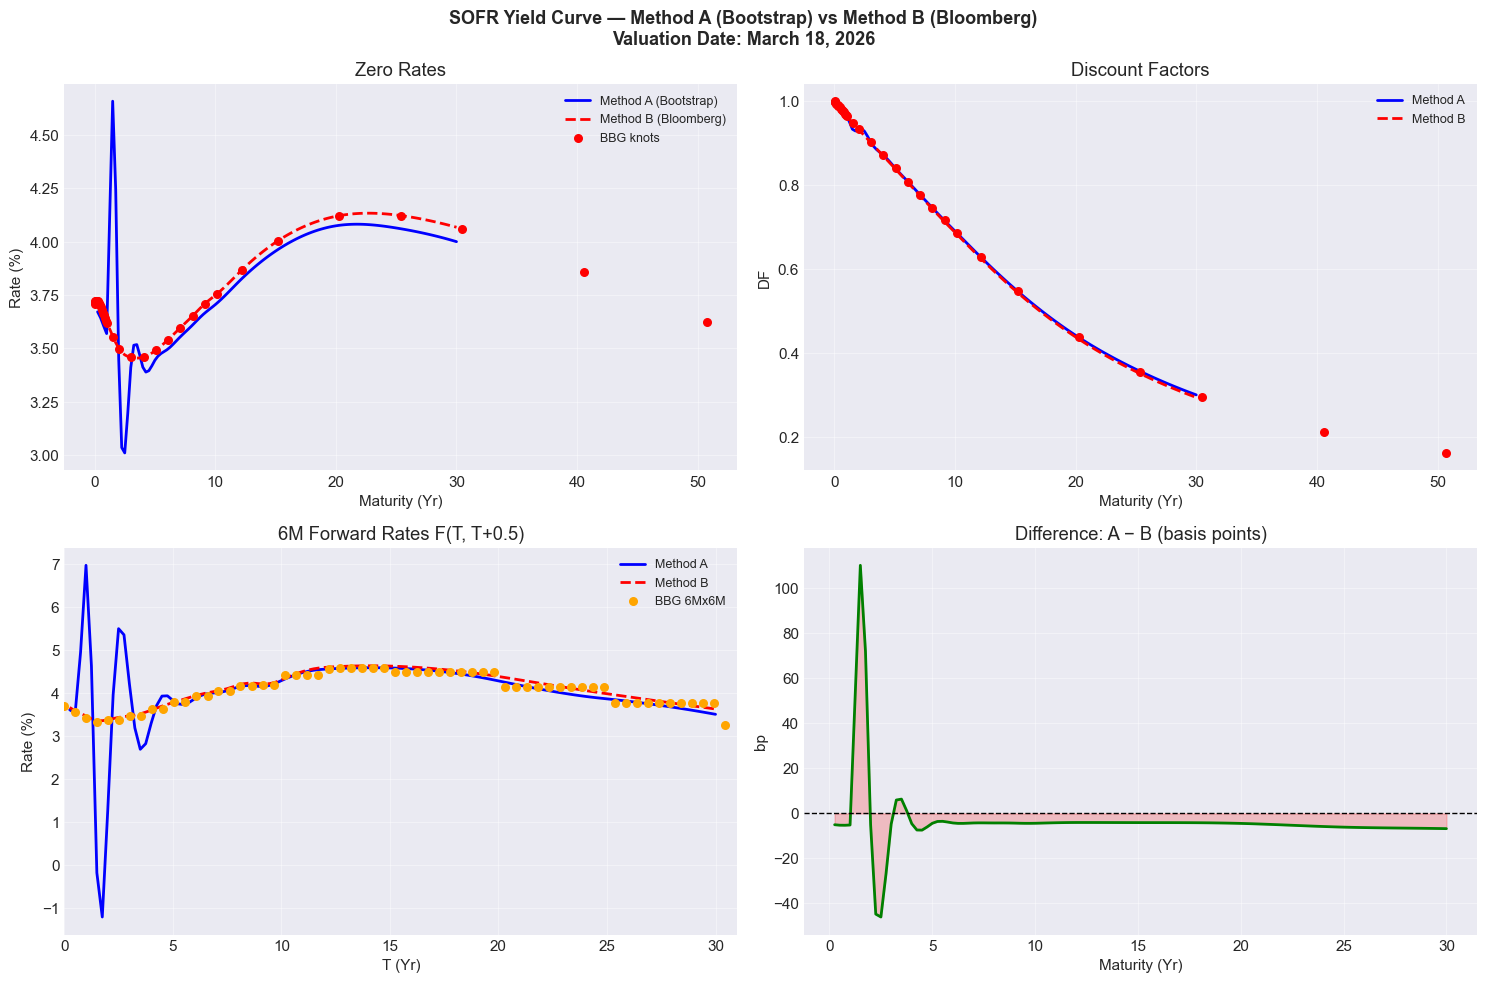

In [40]:
# ── 4-panel comparison chart ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('SOFR Yield Curve — Method A (Bootstrap) vs Method B (Bloomberg)\n'
             'Valuation Date: March 18, 2026', fontsize=13, fontweight='bold')

# Zero rates
ax = axes[0, 0]
ax.plot(T_grid, curve_A['Zero']*100, 'b-', lw=2, label='Method A (Bootstrap)')
ax.plot(T_grid, curve_B['Zero']*100, 'r--', lw=2, label='Method B (Bloomberg)')
ax.scatter(bbg['T'], bbg['zero_rate'], color='red', s=30, zorder=5, label='BBG knots')
ax.set_title('Zero Rates'); ax.set_xlabel('Maturity (Yr)'); ax.set_ylabel('Rate (%)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

# Discount factors
ax = axes[0, 1]
ax.plot(T_grid, curve_A['DF'], 'b-', lw=2, label='Method A')
ax.plot(T_grid, curve_B['DF'], 'r--', lw=2, label='Method B')
ax.scatter(bbg['T'], bbg['discount_factor'], color='red', s=30, zorder=5)
ax.set_title('Discount Factors'); ax.set_xlabel('Maturity (Yr)'); ax.set_ylabel('DF')
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

# 6M forward rates
ax = axes[1, 0]
ax.plot(T_grid, curve_A['Fwd6m']*100, 'b-', lw=2, label='Method A')
ax.plot(T_grid, curve_B['Fwd6m']*100, 'r--', lw=2, label='Method B')
ax.scatter(fwd_bbg['T'], fwd_bbg['forward_rate_6Mx6M']/100*100,
           color='orange', s=30, zorder=5, label='BBG 6Mx6M')
ax.set_title('6M Forward Rates F(T, T+0.5)'); ax.set_xlabel('T (Yr)'); ax.set_ylabel('Rate (%)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.4); ax.set_xlim(0, 31)

# Difference in basis points
ax = axes[1, 1]
diff = (curve_A['Zero'] - curve_B['Zero']) * 10000
ax.plot(T_grid, diff, 'g-', lw=2)
ax.axhline(0, color='black', lw=1, ls='--')
ax.fill_between(T_grid, diff, 0, alpha=0.2,
                color=np.where(diff >= 0, 'green', 'red')[0])
ax.set_title('Difference: A − B (basis points)'); ax.set_xlabel('Maturity (Yr)'); ax.set_ylabel('bp')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('yield_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Validate Forward Rates vs Bloomberg

In [41]:
# ── Compare our 6M forwards to Bloomberg's forward_rates_6Mx6M.csv ────────
def fwd_from_curve(cs, T_start, delta=0.5):
    z0 = np.maximum(cs(T_start), 0.001)
    z1 = np.maximum(cs(T_start + delta), 0.001)
    df0 = np.exp(-z0 * T_start)
    df1 = np.exp(-z1 * (T_start + delta))
    return (df0 / df1 - 1) / delta

fwd_compare = []
for _, row in fwd_bbg.iterrows():
    T = row['T']
    if T < 0: continue
    bbg_fwd = row['forward_rate_6Mx6M'] / 100
    our_fwd_A = fwd_from_curve(cs_A, T)
    our_fwd_B = fwd_from_curve(cs_B, T)
    fwd_compare.append({
        'Date':         row['date'].strftime('%Y-%m-%d'),
        'T':            round(T, 3),
        'BBG Fwd (%)':  round(bbg_fwd * 100, 4),
        'Method A (%)': round(our_fwd_A * 100, 4),
        'A err (bp)':   round((our_fwd_A - bbg_fwd) * 10000, 2),
        'Method B (%)': round(our_fwd_B * 100, 4),
        'B err (bp)':   round((our_fwd_B - bbg_fwd) * 10000, 2),
    })

fwd_val = pd.DataFrame(fwd_compare)
print('6Mx6M Forward Rate Validation:')
print(fwd_val.to_string(index=False))
print(f'\nMethod A — MAE: {fwd_val["A err (bp)"].abs().mean():.2f} bp')
print(f'Method B — MAE: {fwd_val["B err (bp)"].abs().mean():.2f} bp')

6Mx6M Forward Rate Validation:
      Date      T  BBG Fwd (%)  Method A (%)  A err (bp)  Method B (%)  B err (bp)
2026-03-18  0.000       3.6935        3.6761       -1.74        3.7294        3.59
2026-09-18  0.511       3.5435        3.5381       -0.54        3.5750        3.15
2027-03-18  1.014       3.4258        6.9836      355.78        3.4576        3.18
2027-09-18  1.525       3.3275       -0.5081     -383.56        3.3547        2.72
2028-03-18  2.031       3.3746        1.6173     -175.73        3.3752        0.06
2028-09-18  2.542       3.3757        5.5774      220.17        3.4316        5.59
2029-03-18  3.044       3.4611        3.9938       53.27        3.4650        0.39
2029-09-18  3.556       3.4630        2.6673      -79.57        3.5190        5.60
2030-03-18  4.058       3.6201        3.3994      -22.07        3.6074       -1.27
2030-09-18  4.569       3.6236        3.9440       32.04        3.7014        7.78
2031-03-18  5.072       3.7846        3.7948        1.02

---
## 6. Par Swap Rate Check
Verify our curve reprices the input swap rates accurately.

In [42]:
def par_swap_rate(cs, T_maturity, delta=0.5):
    """Par rate of a fixed-for-float swap: semi-annual float, annual fixed."""
    pay_T = np.arange(delta, T_maturity + delta, delta)
    dfs   = np.array([np.exp(-np.maximum(cs(t), 0.001) * t) for t in pay_T])
    ann   = np.sum(delta * dfs)
    df0   = 1.0
    dfn   = np.exp(-np.maximum(cs(T_maturity), 0.001) * T_maturity)
    return (df0 - dfn) / ann

swap_tenors = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30]
# Market mid rates from curve_construction_inputs
mkt_rates = {int(float(r['term'].replace('Y',''))): r['mid']/100
             for _, r in ois[ois['term'].str.endswith('Y')].iterrows()
             if r['term'].replace('Y','').isdigit()}

rows = []
for t in swap_tenors:
    mkt = mkt_rates.get(t, np.nan)
    sA  = par_swap_rate(cs_A, t)
    sB  = par_swap_rate(cs_B, t)
    rows.append({
        'Tenor': f'{t}Y',
        'Market (%)':  round(mkt*100, 4) if not np.isnan(mkt) else 'n/a',
        'Method A (%)': round(sA*100, 4),
        'A err (bp)':  round((sA-mkt)*10000, 2) if not np.isnan(mkt) else 'n/a',
        'Method B (%)': round(sB*100, 4),
        'B err (bp)':  round((sB-mkt)*10000, 2) if not np.isnan(mkt) else 'n/a',
    })

print('Par Swap Rate Check:')
print(pd.DataFrame(rows).to_string(index=False))

Par Swap Rate Check:
Tenor Market (%)  Method A (%) A err (bp)  Method B (%) B err (bp)
   1Y        n/a        3.6017        n/a        3.6542        n/a
   2Y     3.5122        3.4972      -1.49        3.5341       2.19
   3Y     3.4715        3.4464      -2.52        3.4907       1.92
   5Y     3.5033        3.4766      -2.66        3.5181       1.49
   7Y     3.6014        3.5723      -2.92        3.6130       1.16
  10Y     3.7454        3.7129      -3.24        3.7552       0.99
  15Y      3.958        3.9253      -3.27        3.9651       0.71
  20Y     4.0556        4.0243      -3.13        4.0665       1.09
  25Y     4.0678        4.0302      -3.75        4.0833       1.55
  30Y     4.0402        4.0010      -3.92        4.0591       1.89


In [43]:
# ── Par swap rate grid for SABR calibration ───────────────────────────────
def par_swap_rate_sabr(T_start, tenor_yr, delta=0.5):
    """Forward swap rate starting at T_start, tenor = tenor_yr years."""
    if T_start <= 0:
        df0 = 1.0
    else:
        z0  = np.maximum(cs_B(T_start), 0.001)
        df0 = np.exp(-z0 * T_start)
    pay_T = T_start + np.arange(delta, tenor_yr + delta, delta)
    dfs   = np.array([np.exp(-np.maximum(cs_B(t), 0.001) * t) for t in pay_T])
    ann   = np.sum(delta * dfs)
    dfn   = dfs[-1]
    return (df0 - dfn) / ann

expiry_map = {
    '1Mo': 1/12, '3Mo': 3/12, '6Mo': 6/12, '9Mo': 9/12,
    '1Yr': 1,  '2Yr': 2,  '3Yr': 3,  '4Yr': 4,  '5Yr': 5,
    '6Yr': 6,  '7Yr': 7,  '8Yr': 8,  '9Yr': 9,  '10Yr': 10,
    '12Yr': 12, '15Yr': 15, '20Yr': 20, '25Yr': 25, '30Yr': 30,
}
tenor_map = {
    '1Y': 1, '2Y': 2, '3Y': 3, '4Y': 4, '5Y': 5,
    '7Y': 7, '10Y': 10, '12Y': 12, '15Y': 15,
    '20Y': 20, '25Y': 25, '30Y': 30,
}

par_grid = pd.DataFrame(index=expiry_map.keys(), columns=tenor_map.keys(), dtype=float)
for exp_label, T_exp in expiry_map.items():
    for ten_label, T_ten in tenor_map.items():
        par_grid.loc[exp_label, ten_label] = round(
            par_swap_rate_sabr(T_exp, T_ten) * 100, 4
        )

print('Par Swap Rates (%) for SABR:')
print(par_grid.to_string())

Par Swap Rates (%) for SABR:
          1Y      2Y      3Y      4Y      5Y      7Y     10Y     12Y     15Y     20Y     25Y     30Y
1Mo   3.6354  3.5171  3.4819  3.4851  3.5172  3.6154  3.7586  3.8524  3.9693  4.0692  4.0848  4.0599
3Mo   3.5903  3.4838  3.4644  3.4766  3.5159  3.6202  3.7658  3.8619  3.9776  4.0746  4.0879  4.0616
6Mo   3.5202  3.4435  3.4439  3.4699  3.5183  3.6303  3.7793  3.8779  3.9912  4.0837  4.0933  4.0649
9Mo   3.4586  3.4179  3.4329  3.4717  3.5273  3.6450  3.7965  3.8964  4.0069  4.0942  4.1001  4.0694
1Yr   3.4097  3.4047  3.4310  3.4811  3.5423  3.6639  3.8172  3.9171  4.0243  4.1061  4.1080  4.0749
2Yr   3.3995  3.4422  3.5066  3.5784  3.6486  3.7737  3.9254  4.0166  4.1067  4.1630  4.1482  4.1047
3Yr   3.4864  3.5630  3.6423  3.7167  3.7814  3.8909  4.0450  4.1217  4.1918  4.2209  4.1894  4.1354
4Yr   3.6424  3.7247  3.7993  3.8622  3.9245  4.0164  4.1609  4.2217  4.2707  4.2726  4.2253  4.1613
5Yr   3.8101  3.8823  3.9413  4.0021  4.0409  4.1427  4.2631  

In [44]:
# ── Export: curve grid + par swap rates in one CSV ────────────────────────
export = pd.DataFrame({
    'T':          T_grid,
    'ZeroRate_A': curve_A['Zero'],
    'DF_A':       curve_A['DF'],
    'Fwd6m_A':    curve_A['Fwd6m'],
    'ZeroRate_B': curve_B['Zero'],
    'DF_B':       curve_B['DF'],
    'Fwd6m_B':    curve_B['Fwd6m'],
})
export.to_csv('sofr_curve_output.csv', index=False)

par_grid.to_csv('par_swap_rates_for_sabr.csv')

print('Saved sofr_curve_output.csv  — quarterly curve grid (use DF_B, ZeroRate_B)')
print('Saved par_swap_rates_for_sabr.csv — ATM forward swap rates for each vol cube cell')

Saved sofr_curve_output.csv  — quarterly curve grid (use DF_B, ZeroRate_B)
Saved par_swap_rates_for_sabr.csv — ATM forward swap rates for each vol cube cell
